# Triage de reportes de incidentes viales del C5 (CDMX 2022-2024)

**Proyecto Final - Almacenes y Mineria de Datos**

**Profesora:** Jessica Santizo Galicia
**Ayudantes:** Diego Antonio Villalba Gonzalez y Ares Gael Castro Romero
**Integrante:** Jose Ruben Alfaro Gonzalez — No. de cuenta: 320516436
**Fecha:** 10-06-2026

---

## Notebook 01 - Analisis Exploratorio de Datos (EDA)

### El problema: triage de veracidad de reportes viales

El **Centro de Comando, Control, Computo, Comunicaciones y Contacto Ciudadano (C5)** de la Ciudad de Mexico recibe cientos de miles de reportes de incidentes viales al año. Una fracción grande de esos reportes resulta ser **falsa** o simplemente **informativa**. Alguien llama por un choque que ya se resolvió, una cámara detecta un vehículo que en realidad estaba estacionado, etc. Despachar unidades de emergencia hacia reportes que no son reales **desperdicia recursos** y resta capacidad de respuesta a las emergencias verdaderas.

Este cuaderno explora los datos para entender que información, **disponible en el momento en que entra el reporte** (hora, tipo de incidente, fuente, alcaldía, ubicación), permitiendo así anticipar si un reporte se confirmara como **real** el actuar de las autoridades. Esa es la pregunta del **target**:

> **`REAL = 1`** si el reporte es real (cierre afirmativo, `codigo_cierre == 'A'`),
> **`REAL = 0`** si es falso (`F`) o informativo (`I`).

La semilla `42` se fija para todo muestreo reproducible.

> **Frontera anti-fuga.** Las columnas que solo se conocen *al cerrar* el reporte (`codigo_cierre`, `CIERRE_DESC`, `TIEMPO_CIERRE_MIN`) y `clas_con_f_alarma` (su categoria *FALSA ALARMA* es una clasificacion posterior) se usan **solo para EDA** y nunca como variables del modelo.

## 0. Configuracion

Primero, importamos librerias, fijamos la semilla y resolvemos las rutas a `data/` con `pathlib`, relativas a la ubicacion del notebook (`notebooks/`), para que el cuaderno corra sin importar el directorio de trabajo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

SEMILLA = 42
np.random.seed(SEMILLA)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

# Rutas relativas a la ubicacion del notebook (carpeta notebooks/).
BASE = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA = BASE / "data"
FIGURES = BASE / "figures"
REPORTS = BASE / "reports"
FIGURES.mkdir(exist_ok=True)
REPORTS.mkdir(exist_ok=True)

print("BASE   :", BASE)
print("DATA   :", DATA)
print("Semilla:", SEMILLA)

BASE   : /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM
DATA   : /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/data
Semilla: 42


## 1. Diccionario de datos

A continuación presentamos el diccionario de variables. Este también se encuentra en `reports/diccionario_datos.md`.

| Variable | Tipo | Significado | Valores posibles / rango | Rol |
|---|---|---|---|---|
| `folio` | texto (id) | Identificador unico del reporte. | Cadena tipo `C2C/20211229/00212`. | id (no feature) |
| `FECHA_CREACION` | datetime | Fecha-hora de creacion del reporte. | 2022-01 a 2024-02 (tras depurar). | excluida (id temporal) |
| `codigo_cierre` | categorica | Como cerro el reporte. Base del target. | `A`=Afirmativo (real), `D`=Duplicado (real, ya reportado), `F`=Falso, `I`=Informativo. | excluida (base del target) |
| `CIERRE_DESC` | texto | Descripcion legible de `codigo_cierre`. | Texto libre por codigo. | excluida (id/descriptivo) |
| `REAL` | entero 0/1 | **TARGET.** ¿El reporte es real (afirmativo)? | `1` si `codigo_cierre=='A'`; `0` si `F`/`I`. Definido tras eliminar `D`. | **target** |
| `HORA` | entero | Hora del dia del reporte. | 0-23. | feature (numerica) |
| `MES` | entero | Mes del reporte. | 1-12. | feature (numerica) |
| `ANIO` | entero | Ano del reporte. | 2022-2024. | feature (numerica) |
| `latitud` | float | Latitud del incidente (CDMX). | ~19.09 - 19.63. | feature (numerica / clustering) |
| `longitud` | float | Longitud del incidente (CDMX). | ~ -99.35 - -98.95. | feature (numerica / clustering) |
| `tipo_incidente_c4` | categorica (7) | Tipo grueso de incidente. | Accidente, Lesionado, Cadaver, Detencion ciudadana, Mi Calle, Sismo, Mi Taxi. | feature |
| `incidente_c4` | categorica (16) | Subtipo detallado del incidente. | Choque sin/con lesionados, Atropellado, Motociclista, Volcadura, Ciclista, Persona atrapada/desbarrancada, Vehiculo atrapado/varado, Choque con prensados, Accidente automovilistico, Incidente de transito, Vehiculo desbarrancado, Otros, Monopatin, Ferroviario, Persona atropellada. | feature |
| `tipo_entrada` | categorica (~9) | Canal por el que entro el reporte. | LLAMADA DEL 911 (mayoria), BOTON DE AUXILIO, RADIO, CAMARA, REDES, APLICATIVOS, LLAMADA APP911, SOS MUJERES *765, LECTOR DE PLACAS. (3 nulos.) | feature |
| `alcaldia_catalogo` | categorica (16) | Alcaldia de CDMX del incidente. | Las 16 alcaldias (Iztapalapa, Gustavo A. Madero, Cuauhtemoc, ... Milpa Alta). (366 nulos.) | feature |
| `dia_semana` | categorica (7) | Dia de la semana del reporte. | Lunes...Domingo. | feature |
| `FRANJA` | categorica (4) | Franja horaria (derivada de `HORA`). | Madrugada, Mañana, Tarde, Noche. | feature |
| `clas_con_f_alarma` | categorica | Clasificacion operativa (con falsa alarma). | URGENCIAS MEDICAS, EMERGENCIA, DELITO, FALSA ALARMA, INCIDENTES EXTERNOS. | excluida (fuga fina) |
| `TIEMPO_CIERRE_MIN` | float (min) | Tiempo hasta cerrar el reporte. | Minutos > 0 (2 nulos). | excluida (fuga gruesa) |

**Decisiones de rol clave:** El target `REAL` se define **tras eliminar los duplicados** `D` (lo justificamos en la seccion 2). Además, `clas_con_f_alarma` y `TIEMPO_CIERRE_MIN` se **excluyen del modelo por fuga**, pues la primera es una clasificacion posterior al cierre (su categoria *FALSA ALARMA* delata el desenlace) y la segunda solo se conoce cuando el reporte ya cerro. `folio`, `FECHA_CREACION`, `codigo_cierre` y `CIERRE_DESC` son identificadores o la base del target.

### 1.1 Respaldo empirico del diccionario

Verificamos los tipos reales de cada columna y los valores efectivos de las categoricas clave y las numericas. Cargamos directamente el dataset de trabajo ya depurado `c5_listo.parquet`.

In [2]:
df = pd.read_parquet(DATA / "c5_listo.parquet")
print("Dimensiones del dataset de trabajo (c5_listo):", df.shape)

# Tipos por variable (respaldo del diccionario).
df.dtypes.astype(str).rename("dtype").to_frame()

Dimensiones del dataset de trabajo (c5_listo): (289885, 18)


,dtype
folio,string
REAL,int8
CIERRE_DESC,str
codigo_cierre,string
HORA,int16
MES,int16
ANIO,int16
latitud,Float64
longitud,Float64
tipo_incidente_c4,str


In [3]:
# Valores reales de las categoricas clave (respaldo de "valores posibles").
for col in ["codigo_cierre", "tipo_incidente_c4", "tipo_entrada", "FRANJA", "dia_semana"]:
    print(f"\n### {col}  ({df[col].nunique(dropna=True)} categorias)")
    print(df[col].value_counts(dropna=False).head(12).to_string())


### codigo_cierre  (3 categorias)
codigo_cierre
A    184067
F    102211
I      3607

### tipo_incidente_c4  (7 categorias)
tipo_incidente_c4
Accidente              262447
Lesionado               25848
Cadáver                  1052
Mi Calle                  307
Detención ciudadana       122
Mi Taxi                    56
Sismo                      53

### tipo_entrada  (9 categorias)
tipo_entrada
LLAMADA DEL 911     253917
RADIO                19541
BOTÓN DE AUXILIO     14256
CÁMARA                1188
APLICATIVOS            504
REDES                  438
LLAMADA APP911          35
NaN                      3
SOS MUJERES *765         2
LECTOR DE PLACAS         1

### FRANJA  (4 categorias)
FRANJA
Noche        97325
Tarde        95820
Mañana       66177
Madrugada    30563

### dia_semana  (7 categorias)
dia_semana
Viernes      46428
Sábado       46329
Jueves       40381
Miércoles    39903
Domingo      39682
Martes       39468
Lunes        37694


In [4]:
# Rango/estadistica de las numericas (respaldo de "rango").
df[["HORA", "MES", "ANIO", "latitud", "longitud", "TIEMPO_CIERRE_MIN"]].describe().T

,count,mean,std,min,25%,50%,75%,max
HORA,289885.0,13.850441,6.084333,0.0,9.0,15.0,19.0,23.0
MES,289885.0,6.369547,3.58989,1.0,3.0,6.0,10.0,12.0
ANIO,289885.0,2022.6167,0.619983,2022.0,2022.0,2023.0,2023.0,2024.0
latitud,289885.0,19.381961,0.071024,19.094877,19.333475,19.38364,19.43398,19.632201
longitud,289885.0,-99.134408,0.062507,-99.35257,-99.17557,-99.137497,-99.092705,-98.94639
TIEMPO_CIERRE_MIN,289883.0,296.862295,340.365014,0.316667,184.7,188.783333,225.8,4657.133333


In [5]:
# Escribimos el mismo diccionario a reports/diccionario_datos.md (tabla markdown).
diccionario_md = """# Diccionario de datos - C5 incidentes viales (CDMX 2022-2024)

**Proyecto Final - Almacenes y Mineria de Datos.** Profesora: Jessica Santizo Galicia.
Ayudantes: Diego Antonio Villalba Gonzalez y Ares Gael Castro Romero. Fecha: 2026-06.

Documenta cada variable, su significado, los valores que puede tomar y su rol
(target / feature / excluida / id). Dataset de trabajo: data/c5_listo.parquet
(289,885 filas, sin duplicados y sin el ano-ruido 2021).

| Variable | Tipo | Significado | Valores posibles / rango | Rol |
|---|---|---|---|---|
| `folio` | texto (id) | Identificador unico del reporte. | Cadena tipo C2C/20211229/00212. | id (no feature) |
| `FECHA_CREACION` | datetime | Fecha-hora de creacion del reporte. | 2022-01 a 2024-02 (tras depurar). | excluida (id temporal) |
| `codigo_cierre` | categorica | Como cerro el reporte. Base del target. | A=Afirmativo (real), D=Duplicado (real, ya reportado), F=Falso, I=Informativo. | excluida (base del target) |
| `CIERRE_DESC` | texto | Descripcion legible de codigo_cierre. | Texto libre por codigo. | excluida (descriptivo) |
| `REAL` | entero 0/1 | TARGET: el reporte es real (afirmativo)? | 1 si codigo_cierre=='A'; 0 si F/I. Definido tras quitar D. | target |
| `HORA` | entero | Hora del dia del reporte. | 0-23. | feature (num) |
| `MES` | entero | Mes del reporte. | 1-12. | feature (num) |
| `ANIO` | entero | Ano del reporte. | 2022-2024. | feature (num) |
| `latitud` | float | Latitud del incidente (CDMX). | ~19.09-19.63. | feature (num / clustering) |
| `longitud` | float | Longitud del incidente (CDMX). | ~-99.35 a -98.95. | feature (num / clustering) |
| `tipo_incidente_c4` | cat (7) | Tipo grueso de incidente. | Accidente, Lesionado, Cadaver, Detencion ciudadana, Mi Calle, Sismo, Mi Taxi. | feature |
| `incidente_c4` | cat (16) | Subtipo detallado del incidente. | Choque sin/con lesionados, Atropellado, Motociclista, Volcadura, Ciclista, Persona atrapada/desbarrancada, Vehiculo atrapado/varado, Choque con prensados, Accidente automovilistico, Incidente de transito, Vehiculo desbarrancado, Otros, Monopatin, Ferroviario, Persona atropellada. | feature |
| `tipo_entrada` | cat (~9) | Canal por el que entro el reporte. | LLAMADA DEL 911 (mayoria), BOTON DE AUXILIO, RADIO, CAMARA, REDES, APLICATIVOS, LLAMADA APP911, SOS MUJERES *765, LECTOR DE PLACAS. (3 nulos.) | feature |
| `alcaldia_catalogo` | cat (16) | Alcaldia de CDMX del incidente. | Las 16 alcaldias (Iztapalapa, Gustavo A. Madero, Cuauhtemoc, ... Milpa Alta). (366 nulos.) | feature |
| `dia_semana` | cat (7) | Dia de la semana del reporte. | Lunes...Domingo. | feature |
| `FRANJA` | cat (4) | Franja horaria (derivada de HORA). | Madrugada, Mañana, Tarde, Noche. | feature |
| `clas_con_f_alarma` | categorica | Clasificacion operativa (con falsa alarma). | URGENCIAS MEDICAS, EMERGENCIA, DELITO, FALSA ALARMA, INCIDENTES EXTERNOS. | excluida (fuga fina) |
| `TIEMPO_CIERRE_MIN` | float (min) | Tiempo hasta cerrar el reporte. | Minutos > 0 (2 nulos). | excluida (fuga gruesa) |

## Notas de rol

- TARGET (REAL): se define tras ELIMINAR los duplicados D. Un cierre D es un evento real
  ya reportado; su deduplicacion es tarea del sistema de despacho, no del modelo de
  veracidad. Entre el resto, REAL=1 si 'A' (afirmativo), 0 si 'F'/'I'.
- Excluidas por fuga: clas_con_f_alarma (fuga fina: 'FALSA ALARMA' es clasificacion
  posterior al cierre) y TIEMPO_CIERRE_MIN (fuga gruesa: solo se conoce al cerrar).
- Excluidas por ser id o base del target: folio, FECHA_CREACION, codigo_cierre, CIERRE_DESC.

## Features del modelo
- Numericas: HORA, MES, ANIO, latitud, longitud.
- Categoricas: tipo_incidente_c4, incidente_c4, tipo_entrada, alcaldia_catalogo, dia_semana, FRANJA.
"""
(REPORTS / "diccionario_datos.md").write_text(diccionario_md, encoding="utf-8")
print("Diccionario escrito en:", REPORTS / "diccionario_datos.md")

Diccionario escrito en: /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/reports/diccionario_datos.md


## 2. Preparacion de datos

Aqui mostramos **como** se obtuvo el dataset de trabajo a partir del dataset crudo de modelado, aplicando el **patron de diseno Pipeline**. Encadenamos pasos (cada uno una funcion `df -> df`) en orden, registrando las filas antes y despues de cada paso en una **bitacora auditable**.

Partimos de `c5_modelado.parquet` (504,261 filas, **antes** de depurar: conserva `codigo_cierre` y todas las columnas).

In [6]:
crudo = pd.read_parquet(DATA / "c5_modelado.parquet")
print("Dataset de modelado (antes de depurar):", crudo.shape)
crudo[["folio", "codigo_cierre", "ANIO", "tipo_entrada"]].head(3)

Dataset de modelado (antes de depurar): (504261, 18)


,folio,codigo_cierre,ANIO,tipo_entrada
0,C2C/20211229/00212,I,2021,BOTÓN DE AUXILIO
1,C2C/20211231/00183,A,2021,BOTÓN DE AUXILIO
2,C2C/20220101/00012,A,2022,BOTÓN DE AUXILIO


### 2.1 Analisis de `codigo_cierre`: por que eliminamos los duplicados

El target nace de `codigo_cierre`. Veamos su distribucion.

In [7]:
cc = crudo["codigo_cierre"].value_counts(dropna=False)
cc_pct = (crudo["codigo_cierre"].value_counts(normalize=True, dropna=False) * 100).round(2)
tabla_cc = pd.DataFrame({"conteo": cc, "porcentaje": cc_pct})
tabla_cc

,conteo,porcentaje
codigo_cierre,,
D,214326,42.5
A,184097,36.51
F,102230,20.27
I,3608,0.72


**Decision de diseno: los duplicados `D` se eliminan.** La pregunta de negocio es *¿el reporte es real (afirmativo) o falso?*. Un cierre **`D` (Duplicado) es un evento REAL ya reportado**: significa que alguien mas ya levanto ese mismo incidente. Detectar que un reporte entrante coincide con uno ya abierto es tarea del **sistema de despacho** (verificar si ya hay una unidad en el sitio), **no** del modelo de veracidad. Mezclar `D` en el target contaminaria la pregunta: estariamos pidiendo al modelo que prediga "novedad operativa" en vez de "veracidad".

Por eso **eliminamos** los `D` (42.5%) y, entre el resto, definimos:

> `REAL = 1` si `codigo_cierre == 'A'` (afirmativo) · `REAL = 0` si `F` (falso) o `I` (informativo).

**Alternativa descartada.** Si en cambio contaramos `D` como real (`REAL = 1` para `A` y `D`), el balance pasaria a **~79/21** a favor de la clase real: un desbalance mucho peor y, sobre todo, un **target borroso** que confunde veracidad con duplicidad. Preferimos un target limpio y un balance mas manejable (63.5/36.5).

### 2.2 La clase `PipelinePreparacion` y los pasos

Definimos la clase del patron y los tres pasos (`quitar_duplicados`,
`quitar_anio_ruido`, `construir_target`). Cada paso es una funcion pura `df -> df`;
la clase los encadena e imprime la bitacora.

In [8]:
class PipelinePreparacion:
    """Patron de diseno Pipeline: encadena pasos (funcion df->df) en orden,
    registrando filas antes/despues de cada uno (bitacora auditable)."""
    def __init__(self, pasos):
        self.pasos = pasos
        self.bitacora = []
    def aplicar(self, df):
        for nombre, paso in self.pasos:
            antes = len(df)
            df = paso(df)
            self.bitacora.append((nombre, antes, len(df)))
            print(f"  {nombre:28s} {antes:>8,} -> {len(df):>8,}")
        return df


def quitar_duplicados(df):   # 'D' = evento real ya reportado -> dedup es del despacho
    return df[df["codigo_cierre"] != "D"].copy()

def quitar_anio_ruido(df):   # 2021 = decenas de reportes de frontera (dic-2021)
    return df[df["ANIO"] >= 2022].copy()

def construir_target(df):
    df = df.copy()
    df["REAL"] = (df["codigo_cierre"] == "A").astype("int8")
    return df

In [9]:
# Aplicamos el pipeline y observamos la bitacora paso a paso.
pipeline = PipelinePreparacion([
    ("quitar_duplicados", quitar_duplicados),
    ("quitar_anio_ruido", quitar_anio_ruido),
    ("construir_target",  construir_target),
])

print("Bitacora del pipeline de preparacion:")
listo = pipeline.aplicar(crudo)
print("\nResultado final:", listo.shape)
print("Coincide con c5_listo.parquet (289,885 filas):", len(listo) == 289885)

Bitacora del pipeline de preparacion:
  quitar_duplicados             504,261 ->  289,935
  quitar_anio_ruido             289,935 ->  289,885
  construir_target              289,885 ->  289,885

Resultado final: (289885, 18)
Coincide con c5_listo.parquet (289,885 filas): True


**Interpretacion del patron Pipeline.** La bitacora deja la trazabilidad completa: **504,261 -> 289,935 -> 289,885**. 

El primer paso retira los 214,326 duplicados `D`  el segundo elimina los 50 reportes de **2021** (ruido de frontera: unos cuantos reportes con fecha de diciembre-2021 que se colaron en el corte 2022-2024), el tercero construye el target binario `REAL`. Cada paso es una funcion pequeña y verificable, y agregar o quitar un paso es trivial. Por eso preferimos usar este patrón.

El resultado en memoria es **identico** al archivo `data/c5_listo.parquet` que ya cargamos en la seccion 1 (no reescribimos a disco). En adelante seguimos con ese dataset de trabajo de **289,885 filas**.

In [10]:
# Confirmamos el balance del target sobre el dataset depurado.
balance = df["REAL"].value_counts(normalize=True).sort_index()
print("Balance del target REAL:")
print(f"  0 (falso/informativo): {balance[0]:.3f}")
print(f"  1 (afirmativo/real)  : {balance[1]:.3f}")

Balance del target REAL:
  0 (falso/informativo): 0.365
  1 (afirmativo/real)  : 0.635


## 3. Analisis exploratorio (dataset depurado, 289,885 filas)

Algunas funciones auxiliares

In [11]:
# Helpers simples de graficado (inline, estilo Tarea 2).
def barras(serie, titulo, xlabel, ax=None, color="steelblue", rot=0):
    ax = ax or plt.gca()
    serie.plot(kind="bar", ax=ax, color=color, edgecolor="black", linewidth=.4)
    ax.set_title(titulo); ax.set_xlabel(xlabel); ax.set_ylabel("conteo")
    ax.tick_params(axis="x", rotation=rot)
    return ax

def guardar(fig, nombre):
    ruta = FIGURES / nombre
    fig.savefig(ruta, bbox_inches="tight", dpi=120)
    print("Figura guardada:", ruta)

### 3.1 Calidad de los datos: faltantes y duplicados

In [12]:
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
tabla_na = pd.DataFrame({"faltantes": na, "porcentaje": (na / len(df) * 100).round(3)})
print("Faltantes por columna (solo columnas con algun nulo):")
print(tabla_na.to_string())
print("\nFilas exactamente duplicadas:", int(df.duplicated().sum()))
print("Folios duplicados            :", int(df["folio"].duplicated().sum()))

Faltantes por columna (solo columnas con algun nulo):
                   faltantes  porcentaje
alcaldia_catalogo        366       0.126
tipo_entrada               3       0.001
TIEMPO_CIERRE_MIN          2       0.001



Filas exactamente duplicadas: 0
Folios duplicados            : 0


**Interpretacion.** El dataset esta muy limpio. Solo tres columnas tienen faltantes y todos son marginales. `alcaldia_catalogo` (366 nulos, 0.13%) y `tipo_entrada` (3 nulos) son reportes cuya ubicacion o canal no quedo registrado, y `TIEMPO_CIERRE_MIN` (2 nulos) no es feature del modelo. **No hay folios repetidos ni filas identicas**, coherente con que ya retiramos los duplicados `D`. Cada registro es un reporte único. Los nulos de `alcaldia_catalogo`/`tipo_entrada` los maneja el `ColumnTransformer` del notebook 02 con una categoria explicita, asi que no eliminamos filas aqui.

### 3.2 Estadistica descriptiva: `HORA` y `TIEMPO_CIERRE_MIN`

Para las dos numericas mas interesantes reportamos media, mediana, desviacion, cuartiles, rango y forma (asimetria y curtosis con `scipy`).

In [13]:
def resumen_numerico(serie):
    s = serie.dropna().astype("float64")
    return pd.Series({
        "n": len(s),
        "media": s.mean(),
        "mediana": s.median(),
        "std": s.std(),
        "min": s.min(),
        "Q1": s.quantile(.25),
        "Q3": s.quantile(.75),
        "max": s.max(),
        "asimetria": stats.skew(s),
        "curtosis": stats.kurtosis(s),  # exceso de curtosis (normal = 0)
    })

resumen = pd.DataFrame({
    "HORA": resumen_numerico(df["HORA"]),
    "TIEMPO_CIERRE_MIN": resumen_numerico(df["TIEMPO_CIERRE_MIN"]),
}).round(3)
resumen

,HORA,TIEMPO_CIERRE_MIN
n,289885.000,289883.000
media,13.850,296.862
mediana,15.000,188.783
std,6.084,340.365
min,0.000,0.317
Q1,9.000,184.700
Q3,19.000,225.800
max,23.000,4657.133
asimetria,-0.519,3.726
curtosis,-0.580,15.496


**Interpretacion.** `HORA` es casi simetrica (asimetria ~ -0.52) y plana (curtosis negativa ~ -0.58): los reportes se reparten a lo largo del dia con una concentracion vespertina (mediana 15 h). En cambio `TIEMPO_CIERRE_MIN` esta **fuertemente sesgada a la derecha** (asimetria ~ 3.7) y tiene una cola extremadamente cargada a la **derecha** (curtosis ~ 15.5): mediana ~189 min pero con una cola larguisima hasta ~4,657 min.

Esta forma extrema es tipica de tiempos de servicio y, sumada a que solo se conoce **al cerrar** el reporte, refuerza que `TIEMPO_CIERRE_MIN` quede **fuera del modelo** (fuga); aqui la usamos solo como ilustracion de outliers.

### 3.3 Valores atipicos en `TIEMPO_CIERRE_MIN` (boxplot + regla IQR)

Q1=184.7  Q3=225.8  IQR=41.1  limite superior=287.5 min
Outliers (> limite): 49,211  (16.98%)


Figura guardada: /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/figures/01_outliers_tiempo_cierre.png


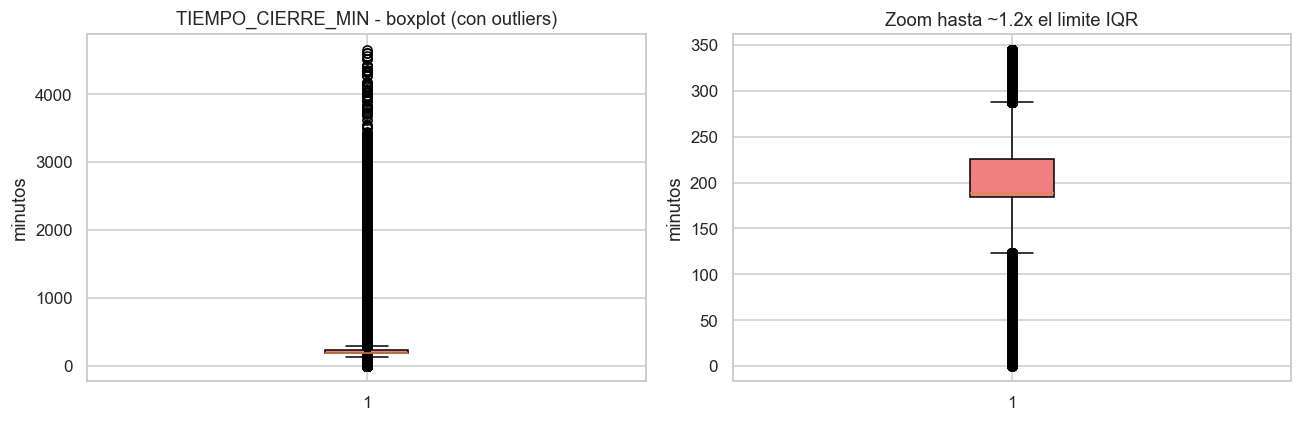

In [14]:
t = df["TIEMPO_CIERRE_MIN"].dropna().astype("float64")
Q1, Q3 = t.quantile(.25), t.quantile(.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
n_out = int((t > lim_sup).sum())
print(f"Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  limite superior={lim_sup:.1f} min")
print(f"Outliers (> limite): {n_out:,}  ({n_out/len(t)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(t, vert=True, showfliers=True, patch_artist=True,
                boxprops=dict(facecolor="lightcoral"))
axes[0].set_title("TIEMPO_CIERRE_MIN - boxplot (con outliers)")
axes[0].set_ylabel("minutos")
# Zoom recortando la cola para ver la caja.
axes[1].boxplot(t.clip(upper=lim_sup * 1.2), vert=True, patch_artist=True,
                boxprops=dict(facecolor="lightcoral"))
axes[1].set_title("Zoom hasta ~1.2x el limite IQR")
axes[1].set_ylabel("minutos")
fig.tight_layout()
guardar(fig, "01_outliers_tiempo_cierre.png")
plt.show()

La regla IQR marca una fraccion notable de reportes con tiempos de cierre extremos (la cola a la derecha del boxplot). No los eliminamos, primero porque `TIEMPO_CIERRE_MIN` no es feature del modelo y segundo, esos tiempos largos son **reales** (reportes complejos que tardan en cerrarse), no errores de captura. Podríamos imaginarnos que en casos donde hubo casualidades la resolución del caso sea más compleja que por ejemplo un choque ligero. El zoom confirma que el grueso de la distribucion vive alrededor de ~3 horas, con una cola operativa larga pero legitima.

### 3.4 Distribuciones: `HORA`, `FRANJA` y `dia_semana`

Figura guardada: /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/figures/01_distribuciones.png


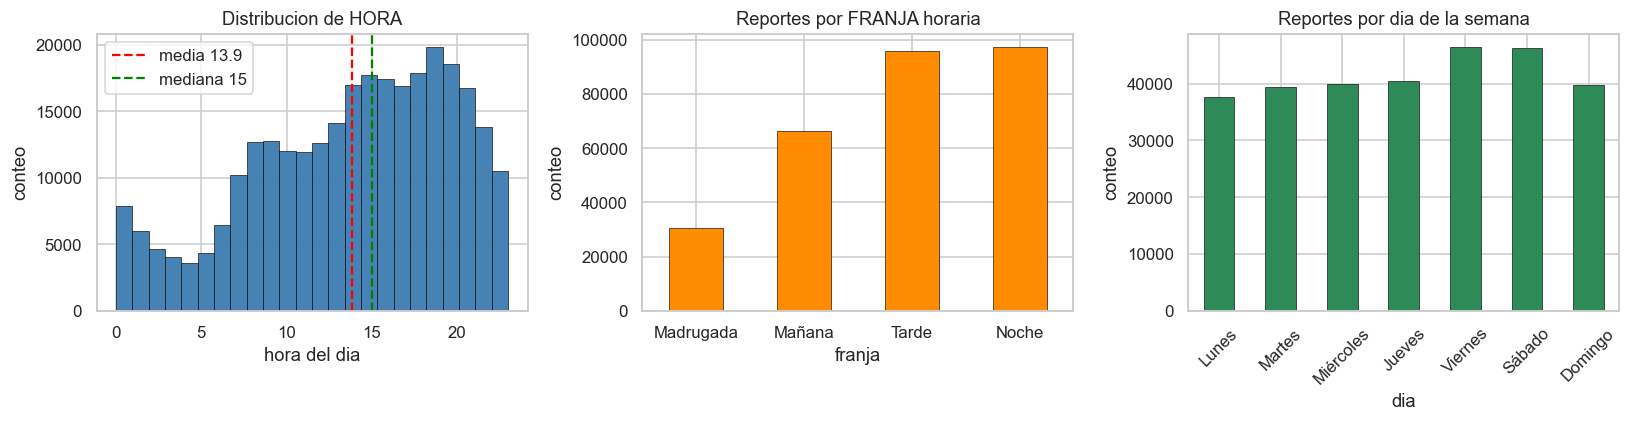

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma de HORA con media y mediana.
axes[0].hist(df["HORA"].astype("float64"), bins=24, color="steelblue",
             edgecolor="black", linewidth=.4)
axes[0].axvline(df["HORA"].mean(), color="red", ls="--", label=f"media {df['HORA'].mean():.1f}")
axes[0].axvline(df["HORA"].median(), color="green", ls="--", label=f"mediana {df['HORA'].median():.0f}")
axes[0].set_title("Distribucion de HORA"); axes[0].set_xlabel("hora del dia")
axes[0].set_ylabel("conteo"); axes[0].legend()

# Barras de FRANJA (orden natural del dia).
orden_franja = ["Madrugada", "Mañana", "Tarde", "Noche"]
fr = df["FRANJA"].value_counts().reindex(orden_franja)
barras(fr, "Reportes por FRANJA horaria", "franja", ax=axes[1], color="darkorange")

# Barras de dia_semana (orden natural).
orden_dia = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
ds = df["dia_semana"].value_counts().reindex(orden_dia)
barras(ds, "Reportes por dia de la semana", "dia", ax=axes[2], color="seagreen", rot=45)

fig.tight_layout()
guardar(fig, "01_distribuciones.png")
plt.show()

**Interpretacion.** En `HORA` hay pocos reportes de madrugada (3-6 h), ascenso a lo largo de la mañana y un grueso concentrado de la tarde a la noche, con la mediana en las 15 h. Eso se refleja en `FRANJA`: **Tarde** y **Noche** acumulan el mayor volumen y la **Madrugada** es la franja mas vacia, siguiendo el ritmo de la actividad vial de la ciudad. Por dia de la semana destacan **viernes y sabado** (mayor movilidad y
vida nocturna), mientras el lunes es el más tranquilo. Son patrones plausibles y utiles como señal temporal moderada para el modelo.

### 3.5 Balance del target `REAL` (decision de diseno)

Figura guardada: /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/figures/01_balance_target.png


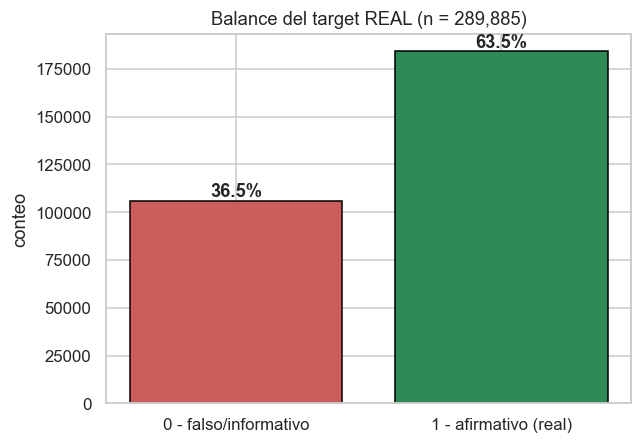

Razon de desbalance (real : no real): 1.74 : 1


In [16]:
vc = df["REAL"].value_counts().sort_index()
prop = df["REAL"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(6, 4.2))
colores = ["indianred", "seagreen"]
bars = ax.bar(["0 - falso/informativo", "1 - afirmativo (real)"], vc.values,
              color=colores, edgecolor="black")
for b, p in zip(bars, prop.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{p*100:.1f}%", ha="center", va="bottom", fontweight="bold")
ax.set_title("Balance del target REAL (n = 289,885)")
ax.set_ylabel("conteo")
fig.tight_layout()
guardar(fig, "01_balance_target.png")
plt.show()

print("Razon de desbalance (real : no real):", round(prop[1] / prop[0], 2), ": 1")

Tras quitar los duplicados, **63.5%** de los reportes son reales (`A`) y **36.5%** son falsos/informativos (`F`/`I`). Hay un desbalance **moderado** (~1.74 : 1) a favor de la clase real. Esto significa que:

> La metrica rectora sera **F1 macro**, porque la *accuracy* podría ser alcanzada casi un clasificador trivial que diga "real" a todo
> Se usara `class_weight='balanced'` para no sacrificar el recall de la clase **no real** (filtrar falsos es justo el valor de negocio).

**Nota:** este balance limpio (63.5/36.5) es preferible al ~79/21 que daria contar los duplicados como reales, como argumentamos en la seccion 2.

## 4. Geografia del reporte: ¿quien reporta, donde y que tan confiable es?

La pregunta de negocio central del EDA: **¿que canal de entrada es mas confiable**, y **como se mezcla con la alcaldia**? Esta seccion cuenta esa historia.

### 4.1 Confiabilidad por canal de entrada (`tipo_entrada`)

Para cada canal calculamos su **volumen** y su **tasa de confirmacion** (% de reportes con `REAL = 1`).

                       n  pct_volumen  pct_real
tipo_entrada                                   
LLAMADA DEL 911   253917        87.59      59.8
RADIO              19541         6.74      93.3
BOTÓN DE AUXILIO   14256         4.92      88.4
CÁMARA              1188         0.41      92.9
APLICATIVOS          504         0.17      28.4
REDES                438         0.15      53.9
LLAMADA APP911        35         0.01      48.6
SOS MUJERES *765       2         0.00     100.0
LECTOR DE PLACAS       1         0.00     100.0
Figura guardada: /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/figures/01_fuente_confirmacion.png


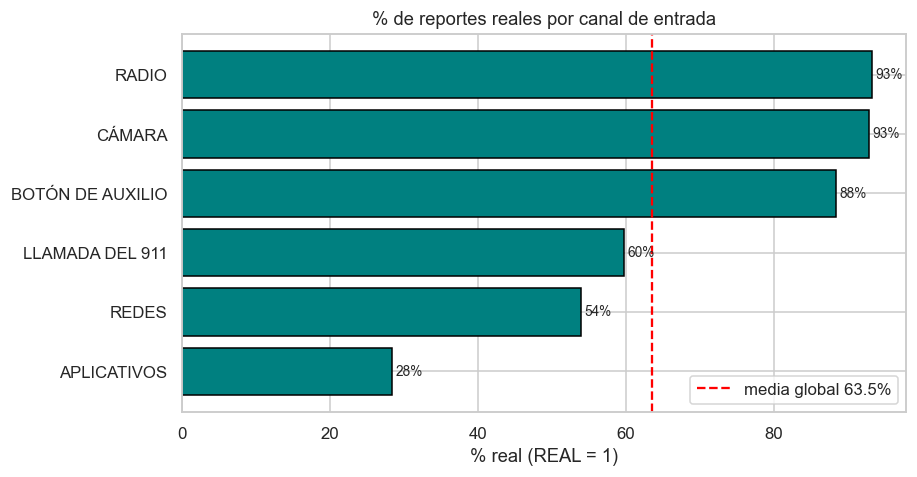

In [17]:
g = (df.groupby("tipo_entrada", observed=True)
        .agg(n=("REAL", "size"), pct_real=("REAL", "mean")))
g["pct_real"] = (g["pct_real"] * 100).round(1)
g["pct_volumen"] = (g["n"] / len(df) * 100).round(2)
g = g.sort_values("n", ascending=False)
print(g[["n", "pct_volumen", "pct_real"]].to_string())

# Solo canales con volumen suficiente para una tasa estable (n >= 100).
g_plot = g[g["n"] >= 100].sort_values("pct_real")
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.barh(g_plot.index, g_plot["pct_real"], color="teal", edgecolor="black")
ax.axvline(df["REAL"].mean() * 100, color="red", ls="--",
           label=f"media global {df['REAL'].mean()*100:.1f}%")
for b, v in zip(bars, g_plot["pct_real"]):
    ax.text(b.get_width() + .5, b.get_y() + b.get_height()/2, f"{v:.0f}%",
            va="center", fontsize=9)
ax.set_title("% de reportes reales por canal de entrada")
ax.set_xlabel("% real (REAL = 1)"); ax.legend()
fig.tight_layout()
guardar(fig, "01_fuente_confirmacion.png")
plt.show()

El **canal es muy informativo**. Los reportes que entran por canales **institucionales** operados por personal del C5 son casi siempre reales: **RADIO ~93%**, **CAMARA ~93%** y **BOTON DE AUXILIO ~88%**. En cambio la **LLAMADA DEL 911**, que es el **~88% del volumen**, confirma solo **~60%**, justo por debajo de la media global. Los aplicativos ciudadanos son los menos confiables (**APLICATIVOS ~28%**). Implicacion operativa directa: se puede despachar de manera casi automatica con **alta prioridad** lo que entra por canales institucionales y aplicar mas escrutinio a la avalancha de llamadas ciudadanas, que es donde se concentra la ambiguedad. La fuente será el predictor más informativo del modelo.

### 4.2 Confiabilidad por alcaldia

Figura guardada: /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/figures/01_alcaldia_confirmacion.png


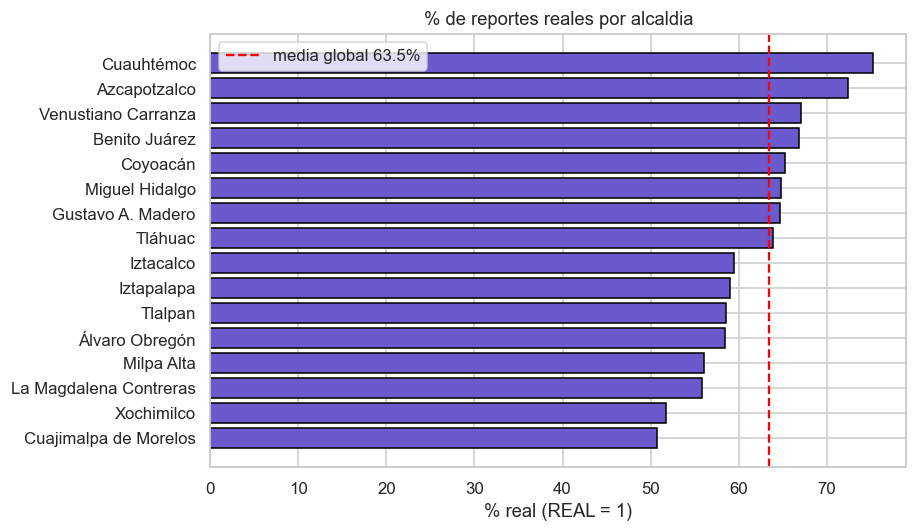

                            n  pct_real
alcaldia_catalogo                      
Cuauhtémoc              32074      75.3
Azcapotzalco            11568      72.4
Venustiano Carranza     21061      67.1
Benito Juárez           20303      66.9
Coyoacán                20336      65.3
Miguel Hidalgo          19725      64.8
Gustavo A. Madero       31421      64.7
Tláhuac                  8870      63.9
Iztacalco               13242      59.5
Iztapalapa              46680      59.0
Tlalpan                 20370      58.6
Álvaro Obregón          19885      58.5
Milpa Alta               2270      56.1
La Magdalena Contreras   4619      55.8
Xochimilco              11202      51.8
Cuajimalpa de Morelos    5893      50.7


In [18]:
a = (df.groupby("alcaldia_catalogo", observed=True)
        .agg(n=("REAL", "size"), pct_real=("REAL", "mean")))
a["pct_real"] = (a["pct_real"] * 100).round(1)
a = a.sort_values("pct_real", ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(a.index[::-1], a["pct_real"][::-1], color="slateblue", edgecolor="black")
ax.axvline(df["REAL"].mean() * 100, color="red", ls="--",
           label=f"media global {df['REAL'].mean()*100:.1f}%")
ax.set_title("% de reportes reales por alcaldia")
ax.set_xlabel("% real (REAL = 1)"); ax.legend()
fig.tight_layout()
guardar(fig, "01_alcaldia_confirmacion.png")
plt.show()
print(a[["n", "pct_real"]].to_string())

Hay heterogeneidad geografica. El ranking va de **Cuauhtemoc (~75%)** y **Azcapotzalco (~72%)** hasta **Cuajimalpa (~51%)** y **Xochimilco (~52%)**, un rango de **~25 puntos**. Las alcaldias centrales con mas camaras, operadores y trafico verificable tienden a mayor tasa de confirmación que la periferia. La diferencia es real pero **menor que la diferencia por canal** (RADIO ~93% vs 911 ~60% son ~33 puntos): la geografia aporta señal **complementaria**, que el clustering del notebook 03 explotara como *hotspots*.

### 4.3 Mezcla canal x alcaldia: heatmap y prueba de independencia

¿La mezcla de canales cambia entre alcaldias? Construimos la tabla de contingencia, la mostramos como heatmap (en % por alcaldia, **excluyendo la LLAMADA DEL 911** que aplastaria la escala con ~88%) y medimos la asociacion con **chi-cuadrado** y la **V de Cramer**.

chi2 = 3,719.8   p-value = 0   dof = 120
V de Cramer = 0.0401  (efecto pequeno < 0.10)
Figura guardada: /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/figures/01_mezcla_canal_alcaldia.png


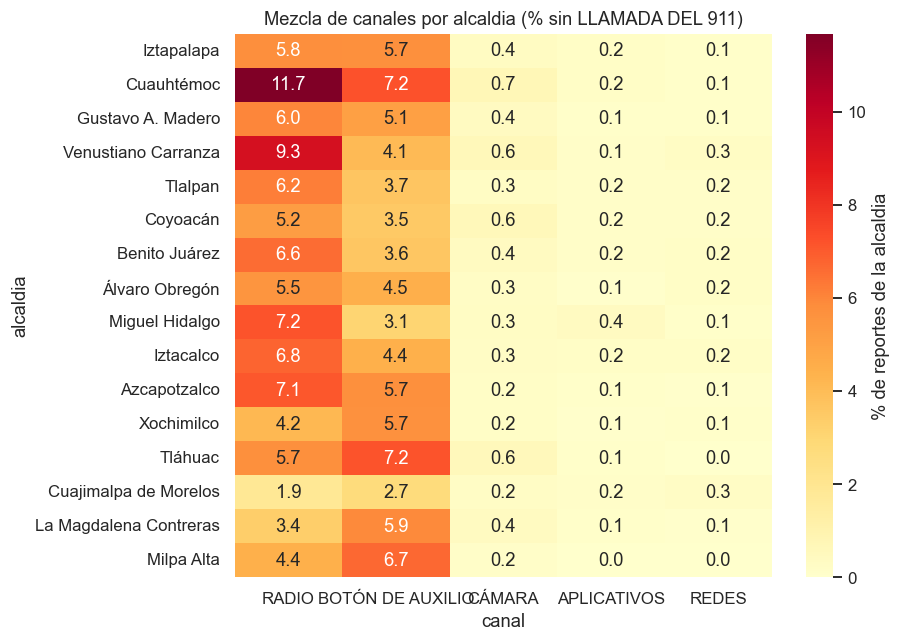

In [19]:
# Tabla de contingencia completa (conteos) para el test.
ct = pd.crosstab(df["alcaldia_catalogo"], df["tipo_entrada"])
chi2, p, dof, _ = stats.chi2_contingency(ct)
n = ct.values.sum()
cramer = np.sqrt((chi2 / n) / (min(ct.shape) - 1))
print(f"chi2 = {chi2:,.1f}   p-value = {p:.3g}   dof = {dof}")
print(f"V de Cramer = {cramer:.4f}  (efecto pequeno < 0.10)")

# Heatmap: % de cada canal dentro de la alcaldia, SIN la LLAMADA DEL 911.
mezcla = ct.div(ct.sum(axis=1), axis=0) * 100  # % sobre el total de la alcaldia
mezcla = mezcla.loc[ct.sum(axis=1).sort_values(ascending=False).index]
# Solo canales (sin 911) con presencia apreciable para un heatmap legible.
canales_vis = [c for c in mezcla.columns if c != "LLAMADA DEL 911"]
canales_vis = mezcla[canales_vis].sum().sort_values(ascending=False).head(5).index
fig, ax = plt.subplots(figsize=(8.5, 6))
sns.heatmap(mezcla[canales_vis], annot=True, fmt=".1f", cmap="YlOrRd",
            cbar_kws={"label": "% de reportes de la alcaldia"}, ax=ax)
ax.set_title("Mezcla de canales por alcaldia (% sin LLAMADA DEL 911)")
ax.set_xlabel("canal"); ax.set_ylabel("alcaldia")
fig.tight_layout()
guardar(fig, "01_mezcla_canal_alcaldia.png")
plt.show()

El p-value es **~0** (rechazo de independencia), es decir, la alcaldia y  el canal **no** son independientes. Pero con **n ~ 290k casi cualquier asociacion sale "significativa"**, asi que lo que importa es el **tamano de efecto**: la **V de Cramer ~ 0.04** es muy pequeña. Es decir, *si existe* relacion entre donde ocurre el reporte y por que canal entra, la **CAMARA** pesa más en alcaldias centrales como Cuauhtemoc, y el **BOTON DE AUXILIO** comunitario pesa mas en la periferia (Milpa Alta, Tlahuac), pero es **debil en lo global**, porque el dominio aplastante de la LLAMADA DEL 911 (~88% en todas) homogeneiza la mezcla. La geografia modula los canales minoritarios pero no reescribe el patrón dominante.

### 4.4 Canal x franja horaria

¿En que momento del dia reporta cada canal? Normalizamos **por fila** (perfil horario de cada canal) para que el volumen del 911 no aplaste la lectura.

Figura guardada: /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/figures/01_canal_franja.png


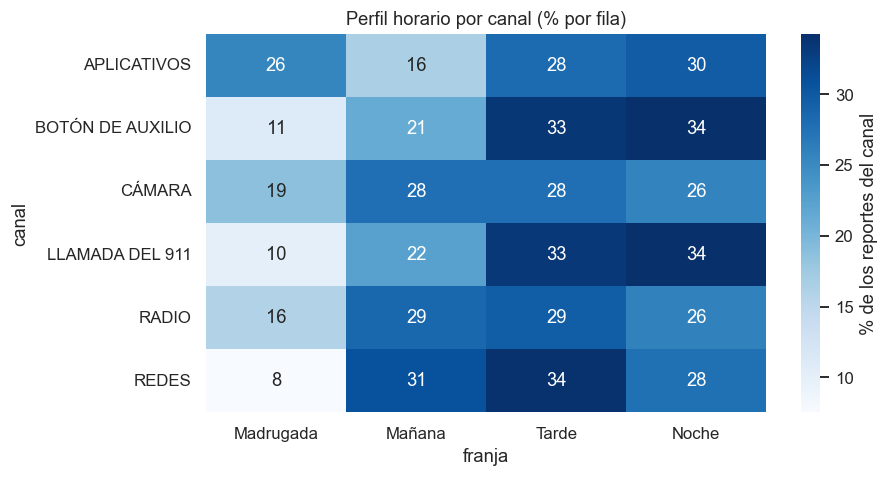

In [20]:
orden_franja = ["Madrugada", "Mañana", "Tarde", "Noche"]
mf = pd.crosstab(df["tipo_entrada"], df["FRANJA"]).reindex(columns=orden_franja)
# Solo canales con volumen suficiente.
mf = mf[mf.sum(axis=1) >= 100]
perfil = mf.div(mf.sum(axis=1), axis=0) * 100  # % por canal

fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.heatmap(perfil, annot=True, fmt=".0f", cmap="Blues",
            cbar_kws={"label": "% de los reportes del canal"}, ax=ax)
ax.set_title("Perfil horario por canal (% por fila)")
ax.set_xlabel("franja"); ax.set_ylabel("canal")
fig.tight_layout()
guardar(fig, "01_canal_franja.png")
plt.show()

La **CAMARA** y la **RADIO** tienen el perfil **mas plano y mas diurno**, con una proporcion relativamente alta en **madrugada-manana**. La **llamada ciudadana** y el **boton de auxilio** se concentran en **tarde-noche**, siguiendo el ritmo de la actividad humana. En otras palabras: **en las horas valle (madrugada) la vigilancia institucional sostiene una proporcion mayor del reporte**, justo cuando hay menos ciudadanos despiertos para llamar, y como esos canales confirman ~90%, la madrugada hereda parte de su alta confiabilidad (coherente con que la franja Madrugada tenga la mayor tasa de % real).

### 4.5 Confiabilidad por franja horaria

Cerramos la geografía del reporte mirando la dimensión **temporal de la confiabilidad**: ¿la proporción de reportes reales cambia según la franja horaria (Madrugada / Mañana / Tarde / Noche)? A diferencia de la sección 4.4 —que describía *qué canal* domina en cada franja—, aquí medimos directamente la **tasa de veracidad** (`% REAL`) por franja.

               n  pct_volumen  pct_real
FRANJA                                 
Madrugada  30563         10.5      70.1
Mañana     66177         22.8      68.3
Tarde      95820         33.1      61.5
Noche      97325         33.6      60.1
Figura guardada: /Users/rou/Desktop/8voSemestre/Almacenes/finalProyectoAyM/figures/01_franja_confirmacion.png


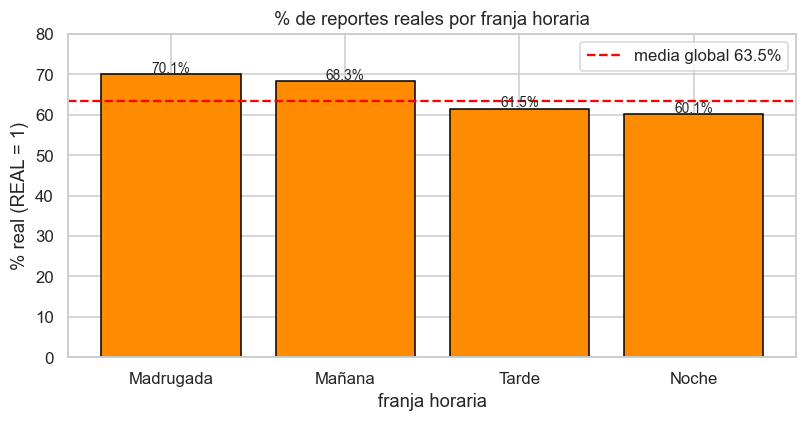

In [21]:
# Confiabilidad (% de reportes reales) por franja horaria.
orden_franja = ["Madrugada", "Mañana", "Tarde", "Noche"]
f = (df.groupby("FRANJA", observed=True)
        .agg(n=("REAL", "size"), pct_real=("REAL", "mean")))
f["pct_real"] = (f["pct_real"] * 100).round(1)
f["pct_volumen"] = (f["n"] / len(df) * 100).round(1)
f = f.reindex(orden_franja)
print(f[["n", "pct_volumen", "pct_real"]].to_string())

fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(f.index, f["pct_real"], color="darkorange", edgecolor="black")
ax.axhline(df["REAL"].mean() * 100, color="red", ls="--",
           label=f"media global {df['REAL'].mean()*100:.1f}%")
for b, v in zip(bars, f["pct_real"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + .4, f"{v:.1f}%",
            ha="center", fontsize=9)
ax.set_title("% de reportes reales por franja horaria")
ax.set_xlabel("franja horaria"); ax.set_ylabel("% real (REAL = 1)")
ax.set_ylim(0, 80); ax.legend()
fig.tight_layout()
guardar(fig, "01_franja_confirmacion.png")
plt.show()

La confiabilidad **decae a lo largo del día**. Los reportes de **madrugada (70.1%)** y **mañana (68.3%)** superan claramente la media global (63.5%), mientras que los de **tarde (61.5%)** y **noche (60.1%)** quedan por debajo. Hay una brecha de **10 puntos** entre la franja más confiable y la menos confiable. El detalle operativo es que tarde y noche concentran además **el mayor volumen** (33.1% y 33.6% de los reportes), es decir, las horas con más reportes son justamente las de menor proporción de incidentes reales y de madrugada llegan pocos reportes pero casi todos genuinos, mientras que en la noche el sistema recibe muchos reportes y una fracción mayor resulta falsa o informativa. La franja horaria aporta así una señal modesta pero coherente para la clasificación, complementaria a la del canal de entrada (sección 4.1).